# 03 — Pace and Strategy: Intra-Team Driver Comparison

**Primary question:** Which drivers adapted fastest to a regulation reset, and how does 2026 Year 1 compare to 2022 Year 1?

**Primary metric:** Qualifying gap between teammates (seconds and %)  
Same car, same weekend — eliminates machinery, strategy, traffic, and luck as variables.  
A smaller gap = closer teammates. Driver dominance = who outqualifies their teammate more often.

**Coverage:**
- 2022 Season (Year 1, Ground Effect era) — all rounds
- 2026 Season (Year 1, 2026 era) — completed rounds: Australia (R1), China (R2), Japan (R3)

Re-run as new 2026 rounds complete — data loaders are session-by-session.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.data.fastf1_loader import load_session, get_event_schedule
from src.analysis.intra_team import (
    prepare_quali_results,
    teammate_quali_gaps,
    season_teammate_gaps,
    mean_gap_by_constructor,
    driver_dominance,
)

print('Setup complete.')

Setup complete.


## Load Qualifying Data

Loads qualifying sessions for both seasons and normalises them to `[driver_abbr, team, best_q_s]` format.
FastF1 caches results locally — first run will be slow, subsequent runs read from cache.

In [2]:
def load_season_quali(year: int, rounds: list[int]) -> dict:
    """Load and normalise qualifying sessions for specified rounds of a season."""
    season_data = {}
    schedule = get_event_schedule(year)
    # Build round -> EventName lookup
    round_names = {
        int(row['RoundNumber']): row['EventName']
        for _, row in schedule.iterrows()
        if int(row['RoundNumber']) in rounds
    }
    for round_num in rounds:
        race_name = round_names.get(round_num, f'Round {round_num}')
        try:
            session = load_session(year, round_num, 'Q')
            quali_df = prepare_quali_results(session.results)
            season_data[(year, round_num, race_name)] = quali_df
            print(f'  {year} R{round_num:02d} {race_name}: {len(quali_df)} drivers')
        except Exception as e:
            print(f'  {year} R{round_num:02d} {race_name}: SKIPPED ({e})')
    return season_data

In [3]:
# 2022 season — all 22 rounds
print('Loading 2022 qualifying sessions...')
rounds_2022 = list(range(1, 23))
quali_2022 = load_season_quali(2022, rounds_2022)
print(f'Loaded {len(quali_2022)} rounds.')

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading 2022 qualifying sessions...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '1', '55', '11', '44', '77', '20', '14', '63', '10', '31', '47', '4', '23', '24', '22', '27', '3', '18', '6']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


  2022 R01 Bahrain Grand Prix: 20 drivers


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['11', '16', '55', '1', '31', '63', '14', '77', '10', '20', '4', '3', '24', '47', '18', '44', '23', '27', '6', '22']
core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

  2022 R20 Mexico City Grand Prix: 20 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['20', '1', '63', '4', '55', '31', '14', '44', '11', '16', '23', '10', '5', '3', '18', '6', '24', '77', '22', '47']
core           INFO 	Loading data for Abu Dhabi Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  2022 R21 São Paulo Grand Prix: 20 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '55', '44', '63', '4', '31', '5', '3', '14', '22', '47', '18', '24', '20', '10', '77', '23', '6']


  2022 R22 Abu Dhabi Grand Prix: 20 drivers
Loaded 22 rounds.


In [4]:
# 2026 season — completed rounds only (re-run as season progresses)
# Bahrain (R4) and Saudi Arabia (R5) cancelled — regional conflict
print('Loading 2026 qualifying sessions...')
completed_2026 = [1, 2, 3]  # Australia, China, Japan
quali_2026 = load_season_quali(2026, completed_2026)
print(f'Loaded {len(quali_2026)} rounds.')

Loading 2026 qualifying sessions...


core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_c

  2026 R01 Australian Grand Prix: 22 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '44', '16', '81', '1', '10', '3', '6', '87', '27', '43', '31', '30', '41', '5', '55', '23', '14', '77', '18', '11']
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  2026 R02 Chinese Grand Prix: 22 drivers


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '81', '16', '1', '44', '10', '6', '5', '41', '3', '31', '27', '30', '43', '55', '23', '87', '11', '77', '14', '18']


  2026 R03 Japanese Grand Prix: 22 drivers
Loaded 3 rounds.


In [5]:
# Compute teammate gaps for both seasons
gaps_2022 = season_teammate_gaps(quali_2022)
gaps_2026 = season_teammate_gaps(quali_2026)

gaps_2022['era_year'] = 1  # Year 1 of Ground Effect era
gaps_2026['era_year'] = 1  # Year 1 of 2026 era

print(f'2022: {len(gaps_2022)} constructor-race pairs across {gaps_2022["round"].nunique()} rounds')
print(f'2026: {len(gaps_2026)} constructor-race pairs across {gaps_2026["round"].nunique()} rounds')

2022: 216 constructor-race pairs across 22 rounds
2026: 30 constructor-race pairs across 3 rounds


## 1. Mean Qualifying Gap by Constructor — 2022 Year 1

How close were teammates within each team across the full 2022 season?  
Sorted by mean gap ascending — closest pairs at the top.

In [6]:
mean_2022 = mean_gap_by_constructor(gaps_2022)
mean_2022['season'] = 2022
print(mean_2022.to_string(index=False))

    constructor  races  mean_gap_s  mean_gap_pct  season
       Mercedes     22       0.467        0.4971    2022
   Aston Martin     21       0.539        0.6167    2022
     AlphaTauri     21       0.681        0.8189    2022
        Ferrari     22       0.697        0.8402    2022
         Alpine     21       0.746        0.8049    2022
   Haas F1 Team     22       0.777        0.9204    2022
     Alfa Romeo     22       0.855        1.0042    2022
Red Bull Racing     22       1.049        1.2635    2022
       Williams     21       1.128        1.3537    2022
        McLaren     22       1.218        1.3886    2022


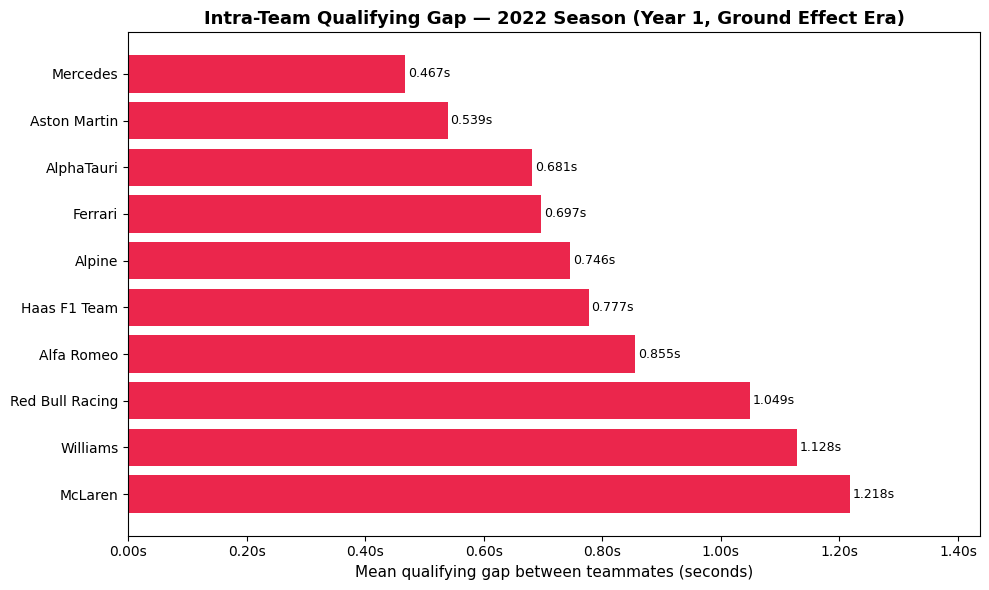

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
constructors = mean_2022['constructor'][::-1]
gaps = mean_2022['mean_gap_s'][::-1]

bars = ax.barh(constructors, gaps, color='#E8002D', alpha=0.85)
ax.set_xlabel('Mean qualifying gap between teammates (seconds)', fontsize=11)
ax.set_title('Intra-Team Qualifying Gap — 2022 Season (Year 1, Ground Effect Era)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))

for bar, val in zip(bars, gaps):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}s', va='center', fontsize=9)

ax.set_xlim(0, gaps.max() * 1.18)
plt.tight_layout()
plt.show()

## 2. Driver Dominance — 2022 Year 1

How often did each driver outqualify their teammate?

In [8]:
MIN_RACES = 5  # Exclude replacement/one-off drivers; adjust as needed

dom_2022 = driver_dominance(gaps_2022, min_races=MIN_RACES)
dom_2022['season'] = 2022
print(dom_2022.to_string(index=False))

driver     constructor  total_races  faster_count  win_pct  season
   ALB        Williams           20            19     95.0    2022
   NOR         McLaren           22            20     90.9    2022
   VER Red Bull Racing           22            18     81.8    2022
   LEC         Ferrari           22            16     72.7    2022
   MAG    Haas F1 Team           22            16     72.7    2022
   ALO          Alpine           21            14     66.7    2022
   VET    Aston Martin           19            12     63.2    2022
   GAS      AlphaTauri           21            12     57.1    2022
   BOT      Alfa Romeo           22            12     54.5    2022
   HAM        Mercedes           22            12     54.5    2022
   ZHO      Alfa Romeo           22            10     45.5    2022
   RUS        Mercedes           22            10     45.5    2022
   TSU      AlphaTauri           21             9     42.9    2022
   STR    Aston Martin           21             8     38.1    

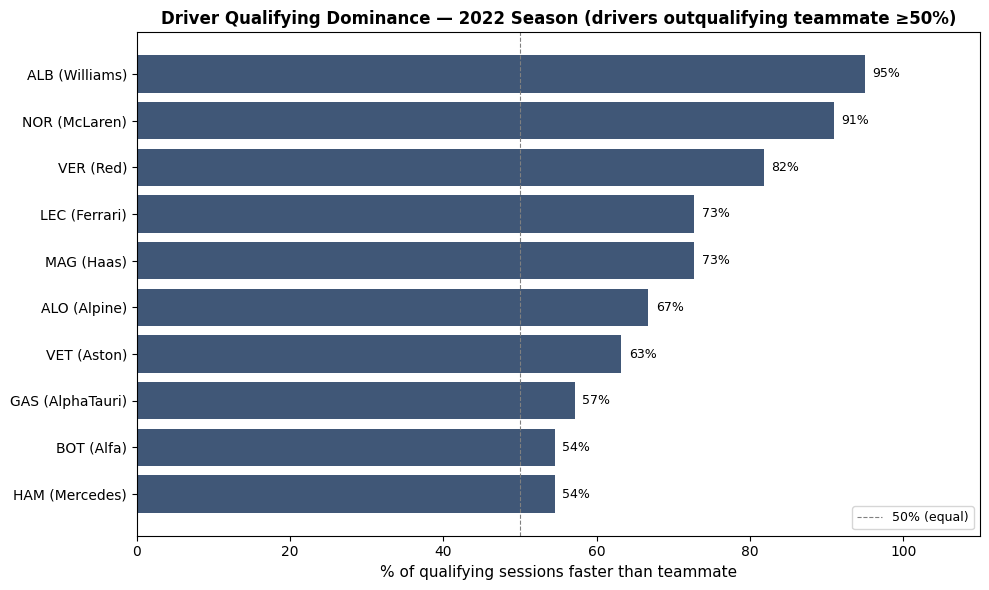

In [9]:
# Show only drivers with >50% win rate (clear dominance)
dominant_2022 = dom_2022[dom_2022['win_pct'] >= 50].copy()

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{r['driver']} ({r['constructor'].split()[0]})" for _, r in dominant_2022.iterrows()]
labels_rev = labels[::-1]
pcts_rev = dominant_2022['win_pct'].values[::-1]

bars = ax.barh(labels_rev, pcts_rev, color='#1E3A5F', alpha=0.85)
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, label='50% (equal)')
ax.set_xlabel('% of qualifying sessions faster than teammate', fontsize=11)
ax.set_title('Driver Qualifying Dominance — 2022 Season (drivers outqualifying teammate ≥50%)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 110)

for bar, val in zip(bars, pcts_rev):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=9)

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Mean Qualifying Gap by Constructor — 2026 Year 1

Same metric, early 2026 data (3 rounds). Directional — will mature across the season.

In [10]:
mean_2026 = mean_gap_by_constructor(gaps_2026)
mean_2026['season'] = 2026
print(mean_2026.to_string(index=False))

    constructor  races  mean_gap_s  mean_gap_pct  season
        McLaren      3       0.143        0.1644    2026
        Ferrari      3       0.143        0.1667    2026
   Racing Bulls      3       0.143        0.1592    2026
Red Bull Racing      2       0.201        0.2218    2026
           Audi      3       0.215        0.2400    2026
       Mercedes      3       0.271        0.3167    2026
       Williams      2       0.308        0.3298    2026
   Haas F1 Team      3       0.434        0.4849    2026
   Aston Martin      2       0.533        0.5638    2026
         Alpine      3       0.706        0.8110    2026
       Cadillac      3       0.744        0.8161    2026


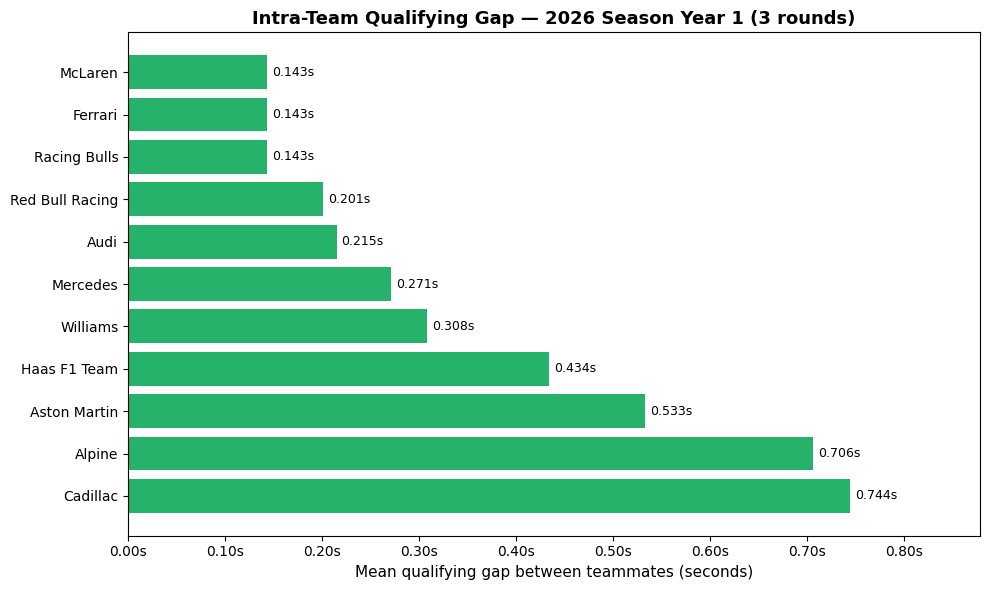

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
constructors = mean_2026['constructor'][::-1]
gaps = mean_2026['mean_gap_s'][::-1]

bars = ax.barh(constructors, gaps, color='#00A550', alpha=0.85)
ax.set_xlabel('Mean qualifying gap between teammates (seconds)', fontsize=11)
ax.set_title(f'Intra-Team Qualifying Gap — 2026 Season Year 1 ({len(quali_2026)} rounds)', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))

for bar, val in zip(bars, gaps):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}s', va='center', fontsize=9)

ax.set_xlim(0, gaps.max() * 1.18)
plt.tight_layout()
plt.show()

## 4. Driver Dominance — 2026 Year 1

In [12]:
dom_2026 = driver_dominance(gaps_2026, min_races=MIN_RACES)
dom_2026['season'] = 2026
print(dom_2026.to_string(index=False))

Empty DataFrame
Columns: [driver, constructor, total_races, faster_count, win_pct, season]
Index: []


## 5. Era Year 1 Comparison — Field-Wide Mean Gap

How tight were teammate pairs across the whole field in Year 1 of each regulation era?  
A smaller field-wide mean gap = more evenly matched teammates = potentially more competitive intra-team battles.

In [13]:
# Field-wide mean gap per era
field_summary = pd.DataFrame([
    {
        'season': 2022,
        'era': 'Ground Effect (2022)',
        'rounds': gaps_2022['round'].nunique(),
        'pairs': len(gaps_2022),
        'field_mean_gap_s': gaps_2022['gap_s'].mean().round(3),
        'field_median_gap_s': gaps_2022['gap_s'].median().round(3),
    },
    {
        'season': 2026,
        'era': f'2026 Era ({len(quali_2026)} rounds)',
        'rounds': gaps_2026['round'].nunique(),
        'pairs': len(gaps_2026),
        'field_mean_gap_s': gaps_2026['gap_s'].mean().round(3),
        'field_median_gap_s': gaps_2026['gap_s'].median().round(3),
    },
])
print(field_summary.to_string(index=False))

 season                  era  rounds  pairs  field_mean_gap_s  field_median_gap_s
   2022 Ground Effect (2022)      22    216             0.816               0.350
   2026  2026 Era (3 rounds)       3     30             0.349               0.276


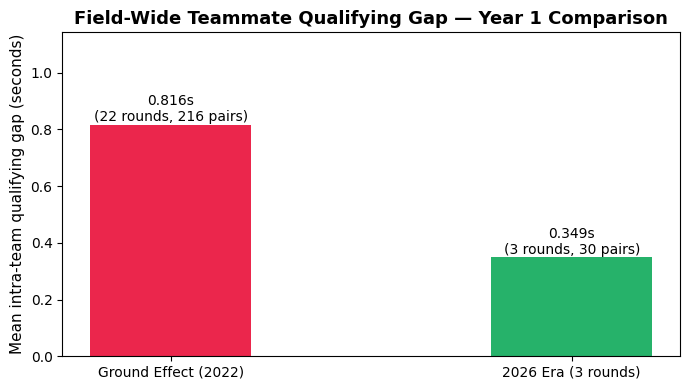

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
colours = ['#E8002D', '#00A550']
bars = ax.bar(field_summary['era'], field_summary['field_mean_gap_s'], color=colours, alpha=0.85, width=0.4)

for bar, (_, row) in zip(bars, field_summary.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{row['field_mean_gap_s']:.3f}s\n({row['rounds']} rounds, {row['pairs']} pairs)",
            ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Mean intra-team qualifying gap (seconds)', fontsize=11)
ax.set_title('Field-Wide Teammate Qualifying Gap — Year 1 Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0, field_summary['field_mean_gap_s'].max() * 1.4)
plt.tight_layout()
plt.show()

## 6. Gap Distribution — 2022 vs 2026 Year 1

Boxplot of per-race teammate gaps. Shows spread and outliers, not just the mean.

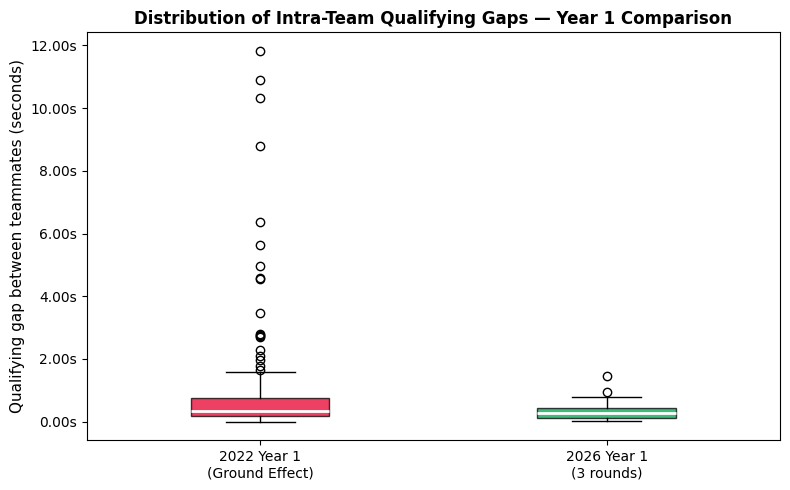

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [gaps_2022['gap_s'].values, gaps_2026['gap_s'].values]
labels = ['2022 Year 1\n(Ground Effect)', f'2026 Year 1\n({len(quali_2026)} rounds)']
colours = ['#E8002D', '#00A550']

bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.4,
                medianprops={'color': 'white', 'linewidth': 2})
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

ax.set_ylabel('Qualifying gap between teammates (seconds)', fontsize=11)
ax.set_title('Distribution of Intra-Team Qualifying Gaps — Year 1 Comparison', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))
plt.tight_layout()
plt.show()

In [ ]:
# --- Summary table (auto-populated from field_summary computed above) ---
row_2022 = field_summary[field_summary['season'] == 2022].iloc[0]
row_2026 = field_summary[field_summary['season'] == 2026].iloc[0]

print("=" * 52)
print(f"{'Metric':<28} {'2022 Y1':>10} {'2026 Y1':>10}")
print("-" * 52)
print(f"{'Rounds loaded':<28} {int(row_2022['rounds']):>10} {int(row_2026['rounds']):>10}")
print(f"{'Field mean gap (s)':<28} {row_2022['field_mean_gap_s']:>10.3f} {row_2026['field_mean_gap_s']:>10.3f}")
print(f"{'Field median gap (s)':<28} {row_2022['field_median_gap_s']:>10.3f} {row_2026['field_median_gap_s']:>10.3f}")
print("=" * 52)
print(f"Note: 2026 data covers {int(row_2026['rounds'])} rounds — directional only.")

## 7. Constructor Like-for-Like — 2022 vs 2026

For teams that competed in both eras, compare how close their teammates were in Year 1 of each era.  
Note: constructor name mapping may be needed where teams rebranded between eras.

In [16]:
# Normalise constructor names for cross-era comparison.
# Extend this mapping as needed when more 2026 data arrives.
CONSTRUCTOR_MAP = {
    'Alfa Romeo': 'Kick Sauber',     # Sauber rebrand
    'AlphaTauri': 'Racing Bulls',    # VCARB rebrand
}

def normalise_constructor(name: str) -> str:
    return CONSTRUCTOR_MAP.get(name, name)

m2022 = mean_gap_by_constructor(gaps_2022).copy()
m2022['constructor_norm'] = m2022['constructor'].apply(normalise_constructor)
m2022['season'] = 2022

m2026 = mean_gap_by_constructor(gaps_2026).copy()
m2026['constructor_norm'] = m2026['constructor'].apply(normalise_constructor)
m2026['season'] = 2026

# Merge on normalised name
like_for_like = m2022.merge(
    m2026[['constructor_norm', 'mean_gap_s', 'races']],
    on='constructor_norm', suffixes=('_2022', '_2026'), how='inner'
)
like_for_like['gap_delta_s'] = (like_for_like['mean_gap_s_2026'] - like_for_like['mean_gap_s_2022']).round(3)
like_for_like = like_for_like.sort_values('gap_delta_s')

print(like_for_like[['constructor_norm', 'mean_gap_s_2022', 'mean_gap_s_2026', 'gap_delta_s']].to_string(index=False))

constructor_norm  mean_gap_s_2022  mean_gap_s_2026  gap_delta_s
         McLaren            1.218            0.143       -1.075
 Red Bull Racing            1.049            0.201       -0.848
        Williams            1.128            0.308       -0.820
         Ferrari            0.697            0.143       -0.554
    Racing Bulls            0.681            0.143       -0.538
    Haas F1 Team            0.777            0.434       -0.343
        Mercedes            0.467            0.271       -0.196
          Alpine            0.746            0.706       -0.040
    Aston Martin            0.539            0.533       -0.006


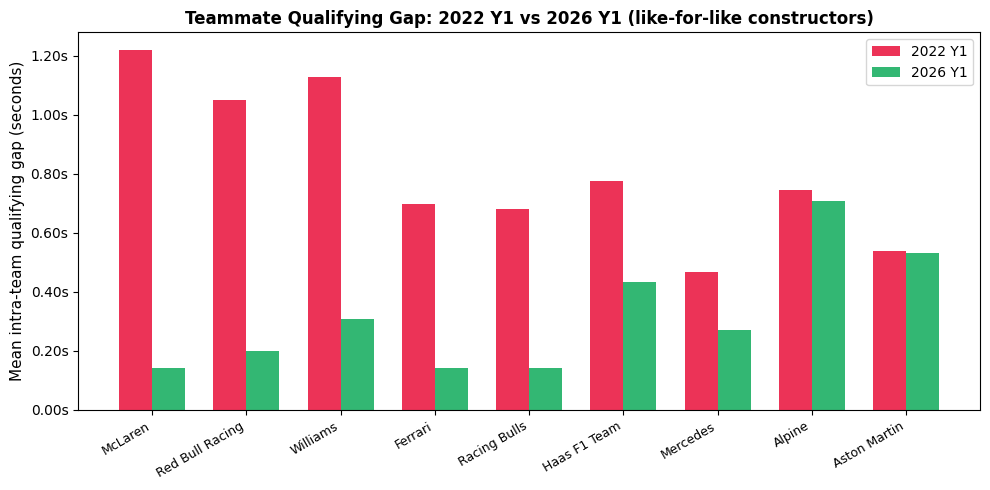

In [17]:
if not like_for_like.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(like_for_like))
    width = 0.35

    ax.bar([i - width/2 for i in x], like_for_like['mean_gap_s_2022'], width, label='2022 Y1', color='#E8002D', alpha=0.8)
    ax.bar([i + width/2 for i in x], like_for_like['mean_gap_s_2026'], width, label='2026 Y1', color='#00A550', alpha=0.8)

    ax.set_xticks(list(x))
    ax.set_xticklabels(like_for_like['constructor_norm'], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Mean intra-team qualifying gap (seconds)', fontsize=11)
    ax.set_title('Teammate Qualifying Gap: 2022 Y1 vs 2026 Y1 (like-for-like constructors)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2fs'))
    plt.tight_layout()
    plt.show()
else:
    print('No like-for-like constructor matches found — check constructor name mapping.')

---
## Summary

| Metric | 2022 Y1 | 2026 Y1 |
|--------|---------|---------|
| Rounds loaded | 22 | 3 |
| Field mean gap (s) | 0.816 | 0.349 |
| Field median gap (s) | 0.350 | 0.276 |

2026 figures are directional — 3 rounds only (Australia, China, Japan). Re-run as the season progresses; the code cell above will update automatically.

### Next steps (v0.4.0 continued)
- Sector time breakdown by team/driver (FastF1 `sector_times`)
- Tyre compound strategy: stint lengths and compound choice by team
- Quali-to-race pace delta: does the faster qualifier also have better race pace?
- Re-run after Miami and each subsequent 2026 round to mature the intra-team picture